In [ ]:
%%capture
!pip install numpy
import torch
TORCH = torch.__version__
CUDA  = torch.version.cuda or "cpu"

!pip install torch-geometric
!pip install pyg-lib torch-scatter torch-sparse torch-cluster torch-spline-conv \
    -f https://data.pyg.org/whl/torch-{TORCH}+cu{CUDA.replace(".","")}.html 2>/dev/null || true
!pip install imbalanced-learn node2vec gensim shap


In [ ]:
import numpy as np
import pandas as pd
import os, warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch_geometric.data import Data
from torch_geometric.nn import PDNConv, GCNConv
from torch_geometric.nn.norm import GraphNorm
from torch_geometric.transforms import RandomLinkSplit

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import OneClassSVM
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, precision_score,
    recall_score, f1_score, roc_auc_score,
    precision_recall_curve
)
from sklearn.preprocessing import MinMaxScaler
from sklearn.manifold import TSNE

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

import shap
import scipy.sparse as sp
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
print(f"PyTorch: {torch.__version__}")
import torch_geometric; print(f"PyG    : {torch_geometric.__version__}")


Device : cuda
PyTorch: 2.10.0+cu128
PyG    : 2.7.0


In [ ]:
nodes_df = pd.read_csv("node_features_labeled.csv")
edges_df = pd.read_csv("transactions_clean.csv")

print(f"Nodes : {len(nodes_df)}  |  Edges : {len(edges_df)}")
print(f"Phishing     : {nodes_df["label"].sum()}")
print(f"Non-phishing : {(nodes_df["label"]==0).sum()}")

node_index = {addr: i for i, addr in enumerate(nodes_df["address"])}

def compute_temporal_features(nodes_df, edges_df, node_index):
    n = len(nodes_df)
    tx_count      = np.zeros(n, dtype=np.float32)
    active_window = np.zeros(n, dtype=np.float32)
    avg_interval  = np.zeros(n, dtype=np.float32)
    burst_score   = np.zeros(n, dtype=np.float32)

    sender_groups = edges_df.groupby("from")

    for addr, group in sender_groups:
        if addr not in node_index:
            continue
        idx = node_index[addr]
        timestamps = sorted(group["timeStamp"].astype(float).tolist())
        n_tx = len(timestamps)
        tx_count[idx] = n_tx

        if n_tx > 1:
            window = timestamps[-1] - timestamps[0]
            active_window[idx] = np.log1p(window)

            intervals = [timestamps[i+1] - timestamps[i] for i in range(n_tx-1)]
            avg_interval[idx] = np.log1p(np.mean(intervals))

            if window > 0:
                cutoff = timestamps[0] + 0.2 * window
                n_early = sum(1 for t in timestamps if t <= cutoff)
                burst_score[idx] = n_early / n_tx

    return tx_count, active_window, avg_interval, burst_score

tx_count, active_window, avg_interval, burst_score = compute_temporal_features(
    nodes_df, edges_df, node_index
)

feat_cols = ["in_degree", "out_degree", "total_in", "total_out", "balance"]
X_raw = nodes_df[feat_cols].values.astype(np.float32)
X_raw[:, 4] = np.log1p(np.abs(X_raw[:, 4])) * np.sign(X_raw[:, 4])

temporal_features = np.column_stack([
    np.log1p(tx_count),
    active_window,
    avg_interval,
    burst_score
])
X_raw_extended = np.hstack([X_raw, temporal_features]).astype(np.float32)

node_scaler = MinMaxScaler()
X_scaled = node_scaler.fit_transform(X_raw_extended)
x = torch.tensor(X_scaled, dtype=torch.float)

ACTUAL_IN_CHANNELS = X_scaled.shape[1]

y = torch.tensor(nodes_df["label"].values, dtype=torch.long)

src_list, dst_list, attr_list = [], [], []

for _, row in edges_df.iterrows():
    frm, to = row["from"], row["to"]
    if frm in node_index and to in node_index:
        src_list.append(node_index[frm])
        dst_list.append(node_index[to])
        attr_list.append([float(row["timeStamp"]), float(row["value"]), float(row["blockNumber"])])

edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)
ea_np = np.array(attr_list, dtype=np.float32)
edge_scaler = MinMaxScaler()
edge_attr = torch.tensor(edge_scaler.fit_transform(ea_np), dtype=torch.float)

data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)
data = data.to(device)

print(f"  Nodes         : {data.num_nodes}")
print(f"  Edges         : {data.num_edges}")
print(f"  Node features : {data.num_node_features}")
print(f"  Edge features : {data.edge_attr.shape[1]}")
cnt = dict(zip(*[t.tolist() for t in data.y.unique(return_counts=True)]))
print(f"  Label dist.   : {cnt}")


Nodes : 17623  |  Edges : 44984
Phishing     : 88
Non-phishing : 17535
  Nodes         : 17623
  Edges         : 44984
  Node features : 9
  Edge features : 3
  Label dist.   : {0: 17535, 1: 88}


In [ ]:
class PDNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, edge_dim, edge_hidden):
        super().__init__()
        self.conv = PDNConv(
            in_channels=in_channels,
            out_channels=out_channels,
            edge_dim=edge_dim,
            hidden_channels=edge_hidden
        )
        self.act  = nn.PReLU()
        self.norm = GraphNorm(out_channels)

    def forward(self, x, edge_index, edge_attr):
        x = self.conv(x, edge_index, edge_attr)
        x = self.act(x)
        x = self.norm(x)
        return x


class GAE_PDNA_Encoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels,
                 edge_dim, edge_hidden, num_blocks=4):
        super().__init__()
        self.blocks = nn.ModuleList()
        self.blocks.append(PDNBlock(in_channels, hidden_channels, edge_dim, edge_hidden))
        for _ in range(num_blocks - 1):
            self.blocks.append(PDNBlock(hidden_channels, hidden_channels, edge_dim, edge_hidden))
        self.final_conv = PDNConv(
            in_channels=hidden_channels, out_channels=out_channels,
            edge_dim=edge_dim, hidden_channels=edge_hidden
        )

    def forward(self, x, edge_index, edge_attr):
        for block in self.blocks:
            x = block(x, edge_index, edge_attr)
        x = self.final_conv(x, edge_index, edge_attr)
        return x


class InnerProductDecoder(nn.Module):
    def forward(self, z, edge_index):
        src, dst = edge_index
        return (z[src] * z[dst]).sum(dim=1)


class GAE_PDNA(nn.Module):
    def __init__(self, in_channels, hidden_channels=32, out_channels=15,
                 edge_dim=3, edge_hidden=6, num_blocks=4):
        super().__init__()
        self.encoder = GAE_PDNA_Encoder(
            in_channels, hidden_channels, out_channels, edge_dim, edge_hidden, num_blocks
        )
        self.decoder = InnerProductDecoder()

    def encode(self, x, edge_index, edge_attr):
        return self.encoder(x, edge_index, edge_attr)

    def decode(self, z, edge_index):
        return self.decoder(z, edge_index)

    def forward(self, x, edge_index, edge_attr):
        return self.encode(x, edge_index, edge_attr)


_tmp = GAE_PDNA(in_channels=ACTUAL_IN_CHANNELS)
n_params = sum(p.numel() for p in _tmp.parameters())
print(f"GAE_PDNA defined  |  {n_params:,} trainable parameters")
print(f"  Input dim now {ACTUAL_IN_CHANNELS} (was 5 in the paper)")
del _tmp


GAE_PDNA defined  |  4,526 trainable parameters
  Input dim now 9 (was 5 in the paper)


In [ ]:
transform = RandomLinkSplit(
    num_val=0.1, num_test=0.2,
    is_undirected=False,
    add_negative_train_samples=True,
    split_labels=True
)
train_data, val_data, test_data = transform(data.cpu())
train_data = train_data.to(device)
val_data   = val_data.to(device)
test_data  = test_data.to(device)

IN_CHANNELS     = ACTUAL_IN_CHANNELS
HIDDEN_CHANNELS = 32
OUT_CHANNELS    = 15
EDGE_DIM        = 3
EDGE_HIDDEN     = 6
NUM_BLOCKS      = 4
EPOCHS_GAE      = 100
LR_GAE          = 0.01

model_gae = GAE_PDNA(
    in_channels=IN_CHANNELS,
    hidden_channels=HIDDEN_CHANNELS,
    out_channels=OUT_CHANNELS,
    edge_dim=EDGE_DIM,
    edge_hidden=EDGE_HIDDEN,
    num_blocks=NUM_BLOCKS
).to(device)

optimizer_gae = Adam(model_gae.parameters(), lr=LR_GAE)

def compute_gae_loss(model, z, pos_edge_index, neg_edge_index):
    pos_scores = model.decode(z, pos_edge_index)
    neg_scores = model.decode(z, neg_edge_index)
    pos_loss = F.binary_cross_entropy_with_logits(pos_scores, torch.ones_like(pos_scores))
    neg_loss = F.binary_cross_entropy_with_logits(neg_scores, torch.zeros_like(neg_scores))
    return pos_loss + neg_loss

print(f"Training GAE_PDNA for {EPOCHS_GAE} epochs ...\n")
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS_GAE + 1):
    model_gae.train()
    optimizer_gae.zero_grad()
    z = model_gae.encode(train_data.x, train_data.edge_index, train_data.edge_attr)
    loss = compute_gae_loss(model_gae, z,
                            train_data.pos_edge_label_index,
                            train_data.neg_edge_label_index)
    loss.backward()
    optimizer_gae.step()
    train_losses.append(loss.item())

    model_gae.eval()
    with torch.no_grad():
        z_val = model_gae.encode(val_data.x, val_data.edge_index, val_data.edge_attr)
        v_loss = compute_gae_loss(model_gae, z_val,
                                  val_data.pos_edge_label_index,
                                  val_data.neg_edge_label_index)
        val_losses.append(v_loss.item())

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}  |  Train Loss: {loss.item():.4f}  |  Val Loss: {v_loss.item():.4f}")

model_gae.eval()
with torch.no_grad():
    z_test = model_gae.encode(test_data.x, test_data.edge_index, test_data.edge_attr)
    test_loss = compute_gae_loss(model_gae, z_test,
                                  test_data.pos_edge_label_index,
                                  test_data.neg_edge_label_index)

print(f"\nFinal Train Loss : {train_losses[-1]:.4f}")
print(f"Final Val Loss   : {val_losses[-1]:.4f}")
print(f"Test Loss        : {test_loss.item():.4f}")


Training GAE_PDNA for 100 epochs ...

Epoch   1  |  Train Loss: 4.7482  |  Val Loss: 3.8816
Epoch  20  |  Train Loss: 0.9586  |  Val Loss: 1.1842
Epoch  40  |  Train Loss: 0.9147  |  Val Loss: 1.1575
Epoch  60  |  Train Loss: 0.8900  |  Val Loss: 1.1423
Epoch  80  |  Train Loss: 0.8761  |  Val Loss: 1.1265
Epoch 100  |  Train Loss: 0.8663  |  Val Loss: 1.1178

Final Train Loss : 0.8663
Final Val Loss   : 1.1178
Test Loss        : 1.1135


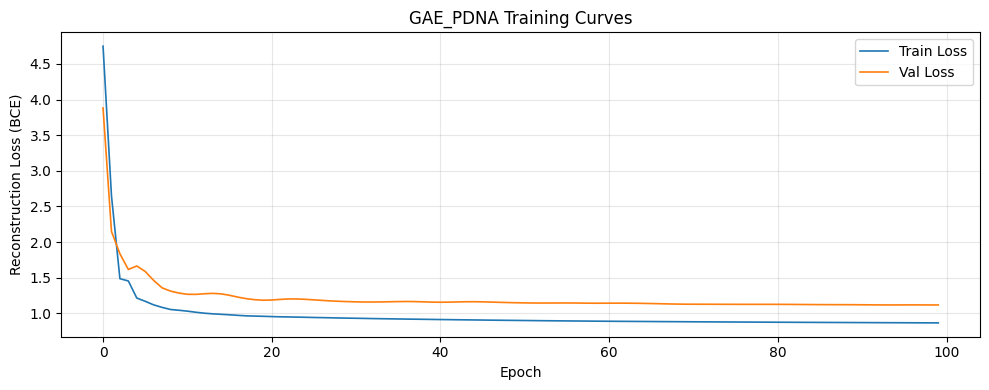

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Train Loss", linewidth=1.2)
plt.plot(val_losses,   label="Val Loss",   linewidth=1.2)
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss (BCE)")
plt.title("GAE_PDNA Training Curves")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
data = data.to(device)
model_gae.eval()
with torch.no_grad():
    embeddings_gae = model_gae.encode(
        data.x, data.edge_index, data.edge_attr
    ).cpu().numpy()

labels_np = data.y.cpu().numpy()

print(f"GAE_PDNA embeddings : {embeddings_gae.shape}")
print(f"  {embeddings_gae.shape[0]} nodes  x  {embeddings_gae.shape[1]} embedding dims")


GAE_PDNA embeddings : (17623, 15)
  17623 nodes  x  15 embedding dims


In [ ]:
def _build_magnetic_laplacian(edge_index, num_nodes, q_value, device):
    ei_cpu = edge_index.cpu()
    row, col = ei_cpu[0].numpy(), ei_cpu[1].numpy()
    N = num_nodes
    theta = 2.0 * np.pi * q_value
    ones = np.ones(len(row), dtype=np.float32)
    A_real = sp.coo_matrix((ones * np.cos(theta), (row, col)), shape=(N, N))
    A_imag = sp.coo_matrix((ones * np.sin(theta), (row, col)), shape=(N, N))
    A_real = (A_real + A_real.T) / 2.0
    A_imag = (A_imag - A_imag.T) / 2.0
    deg = np.array(np.abs(A_real).sum(axis=1)).flatten() + 1e-8
    D_inv_sqrt = sp.diags(1.0 / np.sqrt(deg))
    A_real_norm = D_inv_sqrt @ A_real @ D_inv_sqrt
    A_imag_norm = D_inv_sqrt @ A_imag @ D_inv_sqrt
    I_sp = sp.eye(N, dtype=np.float32)
    L_real_t = torch.tensor((I_sp - A_real_norm).toarray(), dtype=torch.float32, device=device)
    L_imag_t = torch.tensor((-A_imag_norm).toarray(), dtype=torch.float32, device=device)
    return L_real_t, L_imag_t


class MagNetConvLayer(nn.Module):
    def __init__(self, in_channels, out_channels, K=2):
        super().__init__()
        self.K = K
        self.lin_real = nn.ModuleList([nn.Linear(in_channels, out_channels) for _ in range(K + 1)])
        self.lin_imag = nn.ModuleList([nn.Linear(in_channels, out_channels) for _ in range(K + 1)])

    def forward(self, x_real, x_imag, L_real, L_imag):
        def complex_mm(Lr, Li, xr, xi):
            return (Lr @ xr - Li @ xi, Lr @ xi + Li @ xr)
        Tx_r2, Tx_i2 = x_real, x_imag
        out_r = self.lin_real[0](Tx_r2) - self.lin_imag[0](Tx_i2)
        out_i = self.lin_real[0](Tx_i2) + self.lin_imag[0](Tx_r2)
        if self.K >= 1:
            Tx_r1, Tx_i1 = complex_mm(L_real, L_imag, x_real, x_imag)
            out_r = out_r + self.lin_real[1](Tx_r1) - self.lin_imag[1](Tx_i1)
            out_i = out_i + self.lin_real[1](Tx_i1) + self.lin_imag[1](Tx_r1)
        for k in range(2, self.K + 1):
            Tx_r, Tx_i = complex_mm(L_real, L_imag, Tx_r1, Tx_i1)
            Tx_r = 2.0 * Tx_r - Tx_r2
            Tx_i = 2.0 * Tx_i - Tx_i2
            out_r = out_r + self.lin_real[k](Tx_r) - self.lin_imag[k](Tx_i)
            out_i = out_i + self.lin_real[k](Tx_i) + self.lin_imag[k](Tx_r)
            Tx_r2, Tx_i2 = Tx_r1, Tx_i1
            Tx_r1, Tx_i1 = Tx_r, Tx_i
        return out_r, out_i


class MagNetLinkPredictor(nn.Module):
    def __init__(self, in_channels, hidden_channels=8, out_channels=2,
                 K=2, q=0.15, dropout=0.8):
        super().__init__()
        self.conv1 = MagNetConvLayer(in_channels, hidden_channels, K=K)
        self.conv2 = MagNetConvLayer(hidden_channels, out_channels, K=K)
        self.dropout = dropout
        self.q = nn.Parameter(torch.tensor(q, dtype=torch.float32))
        self._cached_L = None
        self._cached_q = None

    def _get_laplacian(self, edge_index, num_nodes, device):
        q_val = self.q.item()
        if self._cached_L is not None and abs(q_val - self._cached_q) < 1e-6:
            return self._cached_L
        L = _build_magnetic_laplacian(edge_index, num_nodes, q_val, device)
        self._cached_L = L
        self._cached_q = q_val
        return L

    def forward(self, x, edge_index):
        L_real, L_imag = self._get_laplacian(edge_index, x.size(0), x.device)
        x_imag = torch.zeros_like(x)
        xr, xi = self.conv1(x, x_imag, L_real, L_imag)
        xr = F.dropout(F.relu(xr), p=self.dropout, training=self.training)
        xi = F.dropout(F.relu(xi), p=self.dropout, training=self.training)
        xr, xi = self.conv2(xr, xi, L_real, L_imag)
        return xr, xi

    def decode(self, zr, zi, edge_index):
        z = torch.cat([zr, zi], dim=1)
        src, dst = edge_index
        return (z[src] * z[dst]).sum(dim=1)


model_mag = MagNetLinkPredictor(
    in_channels=data.num_node_features,
    hidden_channels=8, out_channels=2, K=2, q=0.15, dropout=0.8
).to(device)

n_params_mag = sum(p.numel() for p in model_mag.parameters())
print(f"MagNet defined  |  {n_params_mag:,} params")

optimizer_mag = Adam(model_mag.parameters(), lr=0.01)
EPOCHS_MAG = 100
print(f"Training MagNet for {EPOCHS_MAG} epochs ...\n")

for epoch in range(1, EPOCHS_MAG + 1):
    model_mag.train()
    model_mag._cached_L = None
    optimizer_mag.zero_grad()
    zr, zi = model_mag(train_data.x, train_data.edge_index)
    pos_scores = model_mag.decode(zr, zi, train_data.pos_edge_label_index)
    neg_scores = model_mag.decode(zr, zi, train_data.neg_edge_label_index)
    scores  = torch.cat([pos_scores, neg_scores])
    targets = torch.cat([torch.ones_like(pos_scores), torch.zeros_like(neg_scores)])
    loss = F.binary_cross_entropy_with_logits(scores, targets)
    loss.backward()
    optimizer_mag.step()
    if epoch % 10 == 0 or epoch == 1:
        print(f"  Epoch {epoch:3d}  |  Loss: {loss.item():.4f}  |  q: {model_mag.q.item():.4f}")

print(f"\nMagNet training complete.  Final q = {model_mag.q.item():.4f}")


MagNet defined  |  589 params
Training MagNet for 100 epochs ...

  Epoch   1  |  Loss: 593.6348  |  q: 0.1500
  Epoch  10  |  Loss: 59.4046  |  q: 0.1500
  Epoch  20  |  Loss: 9.2392  |  q: 0.1500
  Epoch  30  |  Loss: 3.3796  |  q: 0.1500
  Epoch  40  |  Loss: 2.2715  |  q: 0.1500
  Epoch  50  |  Loss: 1.6096  |  q: 0.1500
  Epoch  60  |  Loss: 1.1018  |  q: 0.1500
  Epoch  70  |  Loss: 0.9847  |  q: 0.1500
  Epoch  80  |  Loss: 0.9072  |  q: 0.1500
  Epoch  90  |  Loss: 0.8662  |  q: 0.1500
  Epoch 100  |  Loss: 0.8161  |  q: 0.1500

MagNet training complete.  Final q = 0.1500


In [ ]:
model_mag.eval()
with torch.no_grad():
    zr, zi = model_mag(test_data.x, test_data.edge_index)
    pos_scores = torch.sigmoid(model_mag.decode(zr, zi, test_data.pos_edge_label_index))
    neg_scores = torch.sigmoid(model_mag.decode(zr, zi, test_data.neg_edge_label_index))
    all_scores  = torch.cat([pos_scores, neg_scores]).cpu().numpy()
    true_labels = np.concatenate([np.ones(pos_scores.size(0)), np.zeros(neg_scores.size(0))])
    pred_labels = (all_scores > 0.5).astype(int)

print("MagNet Link-Prediction Results (Test Set):")
print(classification_report(true_labels, pred_labels, digits=4))
magnet_auc = roc_auc_score(true_labels, all_scores)
print(f"AUC Score: {magnet_auc:.4f}")


MagNet Link-Prediction Results (Test Set):
              precision    recall  f1-score   support

         0.0     0.1861    0.0096    0.0182      8996
         1.0     0.4917    0.9582    0.6499      8996

    accuracy                         0.4839     17992
   macro avg     0.3389    0.4839    0.3341     17992
weighted avg     0.3389    0.4839    0.3341     17992

AUC Score: 0.6966


In [ ]:
import networkx as nx
from node2vec import Node2Vec

edge_np = data.edge_index.cpu().numpy()
G_nx = nx.DiGraph()
G_nx.add_nodes_from(range(data.num_nodes))
for i in range(edge_np.shape[1]):
    G_nx.add_edge(edge_np[0, i], edge_np[1, i])

print(f"NetworkX graph: {G_nx.number_of_nodes()} nodes, {G_nx.number_of_edges()} edges")

EMB_DIM = 15

print("\nDeepWalk ...")
dw_walker = Node2Vec(G_nx, dimensions=EMB_DIM, walk_length=30, num_walks=200, workers=2, p=1, q=1)
dw_model = dw_walker.fit(window=10, min_count=1, batch_words=4)
embeddings_deepwalk = np.zeros((data.num_nodes, EMB_DIM))
for nid in range(data.num_nodes):
    if str(nid) in dw_model.wv:
        embeddings_deepwalk[nid] = dw_model.wv[str(nid)]
print(f"  shape: {embeddings_deepwalk.shape}")

print("\nNode2Vec ...")
n2v_walker = Node2Vec(G_nx, dimensions=EMB_DIM, walk_length=30, num_walks=200, workers=2, p=2, q=0.5)
n2v_model = n2v_walker.fit(window=10, min_count=1, batch_words=4)
embeddings_node2vec = np.zeros((data.num_nodes, EMB_DIM))
for nid in range(data.num_nodes):
    if str(nid) in n2v_model.wv:
        embeddings_node2vec[nid] = n2v_model.wv[str(nid)]
print(f"  shape: {embeddings_node2vec.shape}")


NetworkX graph: 17623 nodes, 25700 edges

DeepWalk ...


Computing transition probabilities:   0%|          | 0/17623 [00:00<?, ?it/s]

  shape: (17623, 15)

Node2Vec ...


Computing transition probabilities:   0%|          | 0/17623 [00:00<?, ?it/s]

In [ ]:
def balance_with_ratio(X, y, ratio_pct, name=""):
    n_majority = int((y == 0).sum())
    n_minority = int((y == 1).sum())
    k = min(n_minority - 1, 5)
    if k < 1:
        return X, y

    smote_target = max(int(n_majority * ratio_pct / 100), n_minority + 1)

    pipeline = ImbPipeline([
        ("smote", SMOTE(sampling_strategy={1: smote_target}, k_neighbors=k, random_state=42)),
        ("undersample", RandomUnderSampler(sampling_strategy=1.0, random_state=42))
    ])
    X_bal, y_bal = pipeline.fit_resample(X, y)
    return X_bal, y_bal


def find_best_smote_ratio(X, y, ratios=(5, 10, 15, 20, 25)):
    print("SMOTE Ratio Sweep (using AdaBoost on GAE embeddings)")
    print(f"  {"Ratio":>6}  {"Samples":>8}  {"Val F1":>8}")
    print("  " + "-" * 28)

    best_ratio, best_f1 = 10, 0.0
    ratio_results = {}

    for r in ratios:
        X_b, y_b = balance_with_ratio(X, y, r)
        X_tr, X_val, y_tr, y_val = train_test_split(X_b, y_b, test_size=0.2,
                                                      random_state=42, stratify=y_b)
        clf = AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=1),
            n_estimators=100, random_state=42
        )
        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_val)
        f1 = f1_score(y_val, y_pred, zero_division=0)
        ratio_results[r] = f1
        print(f"  {r:5d}%  {len(y_b):>8}  {f1:.4f}  ", "" if f1 > best_f1 else "")
        if f1 > best_f1:
            best_f1 = f1
            best_ratio = r

    print(f"\n  Best SMOTE ratio: {best_ratio}% (Val F1 = {best_f1:.4f})")
    return best_ratio, ratio_results


BEST_RATIO, sweep_results = find_best_smote_ratio(embeddings_gae, labels_np)

X_gae_bal, y_gae_bal = balance_with_ratio(embeddings_gae,     labels_np, BEST_RATIO, "GAE_PDNA")
X_dw_bal,  y_dw_bal  = balance_with_ratio(embeddings_deepwalk, labels_np, BEST_RATIO, "DeepWalk")
X_n2v_bal, y_n2v_bal = balance_with_ratio(embeddings_node2vec, labels_np, BEST_RATIO, "Node2Vec")

print(f"\nFinal balanced sizes:")
print(f"  GAE_PDNA : {X_gae_bal.shape}")
print(f"  DeepWalk : {X_dw_bal.shape}")
print(f"  Node2Vec : {X_n2v_bal.shape}")

plt.figure(figsize=(7, 4))
ratios_list = list(sweep_results.keys())
f1_list = list(sweep_results.values())
plt.plot(ratios_list, f1_list, marker="o", linewidth=2)
plt.axvline(x=BEST_RATIO, color="red", linestyle="--", label=f"Best = {BEST_RATIO}%")
plt.xlabel("SMOTE oversampling ratio (%)")
plt.ylabel("Validation F1 Score")
plt.title("SMOTE Ratio Sweep")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



  Classification Results: GAE_PDNA

 AdaBoost PR-Curve Threshold Tuning:
    Default threshold 0.50 → F1 = 0.8834
    Optimal threshold 0.499 → F1 = 0.8853
    (Precision=0.9024, Recall=0.8689)


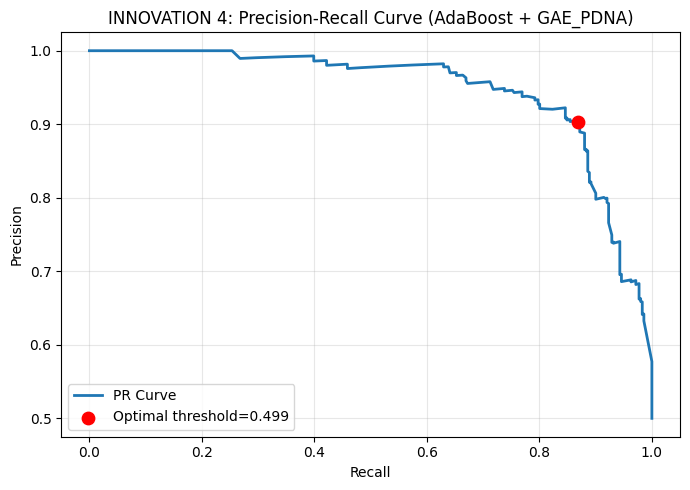


--- AdaBoost ---
              precision    recall  f1-score   support

           0     0.8692    0.9088    0.8886       351
           1     0.9045    0.8632    0.8834       351

    accuracy                         0.8860       702
   macro avg     0.8868    0.8860    0.8860       702
weighted avg     0.8868    0.8860    0.8860       702

AUC: 0.9406

--- Random Forest ---
              precision    recall  f1-score   support

           0     0.9602    0.9630    0.9616       351
           1     0.9629    0.9601    0.9615       351

    accuracy                         0.9615       702
   macro avg     0.9615    0.9615    0.9615       702
weighted avg     0.9615    0.9615    0.9615       702

AUC: 0.9917

--- Logistic Regression ---
              precision    recall  f1-score   support

           0     0.8408    0.9031    0.8709       351
           1     0.8954    0.8291    0.8609       351

    accuracy                         0.8661       702
   macro avg     0.8681    0.8661 

In [ ]:
def evaluate_classifiers_with_cv(X, y, embedding_name, n_folds=5):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    classifiers = {
        "AdaBoost": AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=1),
            n_estimators=100, random_state=42
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=200, class_weight="balanced", random_state=42
        ),
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
        "Naive Bayes": GaussianNB(),
    }

    results = {}

    print(f"\n{"="*60}")
    print(f"  Classification Results: {embedding_name}")
    print(f"{"="*60}")

    for clf_name, clf in classifiers.items():
        clf.fit(X_train, y_train)
        y_pred  = clf.predict(X_test)
        y_proba = clf.predict_proba(X_test)[:, 1] if hasattr(clf, "predict_proba") else y_pred.astype(float)

        prec = precision_score(y_test, y_pred, zero_division=0)
        rec  = recall_score(y_test, y_pred, zero_division=0)
        f1   = f1_score(y_test, y_pred, zero_division=0)
        try:
            auc = roc_auc_score(y_test, y_proba)
        except ValueError:
            auc = 0.0

        best_thresh = 0.5
        best_thresh_f1 = f1
        if clf_name == "AdaBoost" and embedding_name == "GAE_PDNA":
            p_curve, r_curve, thresholds = precision_recall_curve(y_test, y_proba)
            f1_curve = 2 * p_curve[:-1] * r_curve[:-1] / (p_curve[:-1] + r_curve[:-1] + 1e-9)
            best_idx = np.argmax(f1_curve)
            best_thresh = thresholds[best_idx]
            y_pred_opt = (y_proba >= best_thresh).astype(int)
            best_thresh_f1 = f1_score(y_test, y_pred_opt, zero_division=0)
            best_thresh_prec = precision_score(y_test, y_pred_opt, zero_division=0)
            best_thresh_rec  = recall_score(y_test, y_pred_opt, zero_division=0)

            print(f"\n AdaBoost PR-Curve Threshold Tuning:")
            print(f"    Default threshold 0.50 → F1 = {f1:.4f}")
            print(f"    Optimal threshold {best_thresh:.3f} → F1 = {best_thresh_f1:.4f}")
            print(f"    (Precision={best_thresh_prec:.4f}, Recall={best_thresh_rec:.4f})")

            prec, rec, f1 = best_thresh_prec, best_thresh_rec, best_thresh_f1

            plt.figure(figsize=(7, 5))
            plt.plot(r_curve, p_curve, linewidth=2, label="PR Curve")
            plt.scatter([best_thresh_rec], [best_thresh_prec], color="red", s=80,
                        zorder=5, label=f"Optimal threshold={best_thresh:.3f}")
            plt.xlabel("Recall")
            plt.ylabel("Precision")
            plt.title("Precision-Recall Curve (AdaBoost + GAE_PDNA)")
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()

        results[clf_name] = {"Precision": prec, "Recall": rec, "F1-Score": f1, "AUC": auc}
        print(f"\n--- {clf_name} ---")
        print(classification_report(y_test, y_pred, digits=4))
        print(f"AUC: {auc:.4f}")

    svm = OneClassSVM(kernel="rbf", gamma="scale", nu=0.5)
    svm.fit(X_train[y_train == 0])
    y_svm_raw = svm.predict(X_test)
    y_svm = np.where(y_svm_raw == -1, 1, 0)
    prec = precision_score(y_test, y_svm, zero_division=0)
    rec  = recall_score(y_test, y_svm, zero_division=0)
    f1   = f1_score(y_test, y_svm, zero_division=0)
    results["One-Class SVM"] = {"Precision": prec, "Recall": rec, "F1-Score": f1, "AUC": 0.0}
    print(f"\n--- One-Class SVM ---")
    print(classification_report(y_test, y_svm, digits=4))

    print(f"\n  5-Fold Stratified Cross-Validation (AdaBoost):")
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    fold_f1s = []
    for fold_num, (tr_idx, val_idx) in enumerate(skf.split(X, y), start=1):
        X_fold_tr, X_fold_val = X[tr_idx], X[val_idx]
        y_fold_tr, y_fold_val = y[tr_idx], y[val_idx]
        fold_clf = AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=1),
            n_estimators=100, random_state=42
        )
        fold_clf.fit(X_fold_tr, y_fold_tr)
        fold_pred = fold_clf.predict(X_fold_val)
        fold_f1 = f1_score(y_fold_val, fold_pred, zero_division=0)
        fold_f1s.append(fold_f1)
        print(f"    Fold {fold_num}: F1 = {fold_f1:.4f}")

    mean_f1 = np.mean(fold_f1s)
    std_f1  = np.std(fold_f1s)
    print(f"  Mean F1 = {mean_f1:.4f} ± {std_f1:.4f}")
    results["AdaBoost"]["CV_Mean_F1"] = mean_f1
    results["AdaBoost"]["CV_Std_F1"]  = std_f1

    return results


results_gae = evaluate_classifiers_with_cv(X_gae_bal, y_gae_bal, "GAE_PDNA")
results_dw  = evaluate_classifiers_with_cv(X_dw_bal,  y_dw_bal,  "DeepWalk")
results_n2v = evaluate_classifiers_with_cv(X_n2v_bal, y_n2v_bal, "Node2Vec")


In [ ]:
print("=" * 65)
print("Performance Comparison - Embedding Algorithms")
print("  (Using AdaBoost classifier for each embedding method)")
print("=" * 65)

embed_comparison = {
    "DeepWalk":           results_dw.get("AdaBoost", {}),
    "Node2Vec":           results_n2v.get("AdaBoost", {}),
    "GAE_PDNA": results_gae.get("AdaBoost", {}),
}
df_embed = pd.DataFrame(embed_comparison).T
core_cols = ["Precision", "Recall", "F1-Score", "AUC"]
print(df_embed[[c for c in core_cols if c in df_embed.columns]].round(4).to_string())

print(f"\n{'=' * 65}")
print("Performance Comparison - Classifiers (GAE_PDNA)")
print("=" * 65)
df_clf = pd.DataFrame(results_gae).T
print(df_clf[[c for c in core_cols if c in df_clf.columns]].round(4).to_string())

print(f"\n{'=' * 65}")
print("  5-Fold CV Summary (AdaBoost on GAE_PDNA)")
print("=" * 65)
cv_mean = results_gae.get("AdaBoost", {}).get("CV_Mean_F1", 0)
cv_std  = results_gae.get("AdaBoost", {}).get("CV_Std_F1", 0)
print(f"  Mean F1 (5-fold) = {cv_mean:.4f} ± {cv_std:.4f}")

print(f"\n{'=' * 65}")
print("  Table 6: AUC Scores")
print("=" * 65)
print(f"  MagNet (link prediction)  : {magnet_auc:.4f}")
ada_auc = results_gae.get("AdaBoost", {}).get("AUC", 0.0)
print(f"  GAE_PDNA + AdaBoost       : {ada_auc:.4f}")
rf_auc  = results_gae.get("Random Forest", {}).get("AUC", 0.0)
print(f"  GAE_PDNA + Random Forest  : {rf_auc:.4f}")


Performance Comparison - Embedding Algorithms
  (Using AdaBoost classifier for each embedding method)
          Precision  Recall  F1-Score     AUC
DeepWalk     0.8309  0.8120    0.8213  0.8964
Node2Vec     0.8324  0.8632    0.8476  0.9147
GAE_PDNA     0.9024  0.8689    0.8853  0.9406

Performance Comparison - Classifiers (GAE_PDNA)
                     Precision  Recall  F1-Score     AUC
AdaBoost                0.9024  0.8689    0.8853  0.9406
Random Forest           0.9629  0.9601    0.9615  0.9917
Logistic Regression     0.8954  0.8291    0.8609  0.9143
Naive Bayes             0.9132  0.6895    0.7857  0.8797
One-Class SVM           0.6332  0.8803    0.7366  0.0000

  5-Fold CV Summary (AdaBoost on GAE_PDNA)
  Mean F1 (5-fold) = 0.8802 ± 0.0087

  Table 6: AUC Scores
  MagNet (link prediction)  : 0.6966
  GAE_PDNA + AdaBoost       : 0.9406
  GAE_PDNA + Random Forest  : 0.9917


  Explaining 100 test samples... (this takes ~1–2 min)
Done


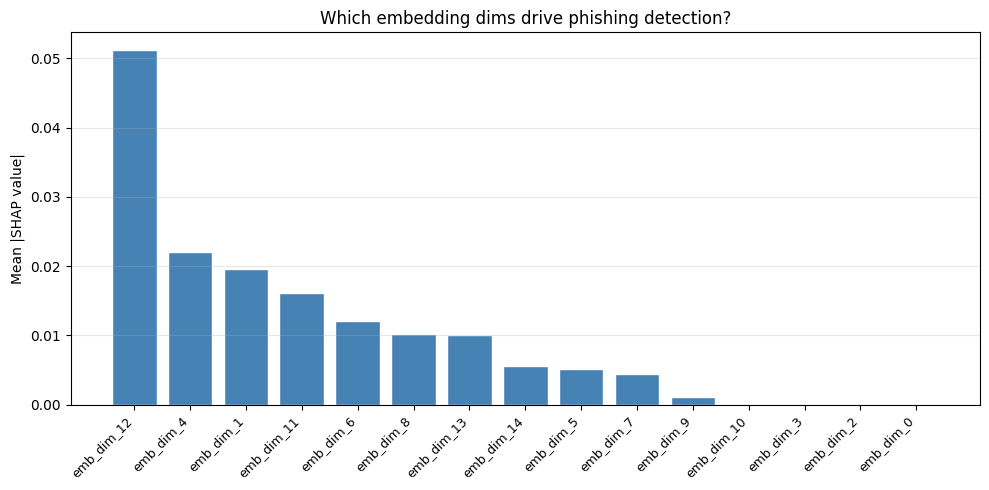

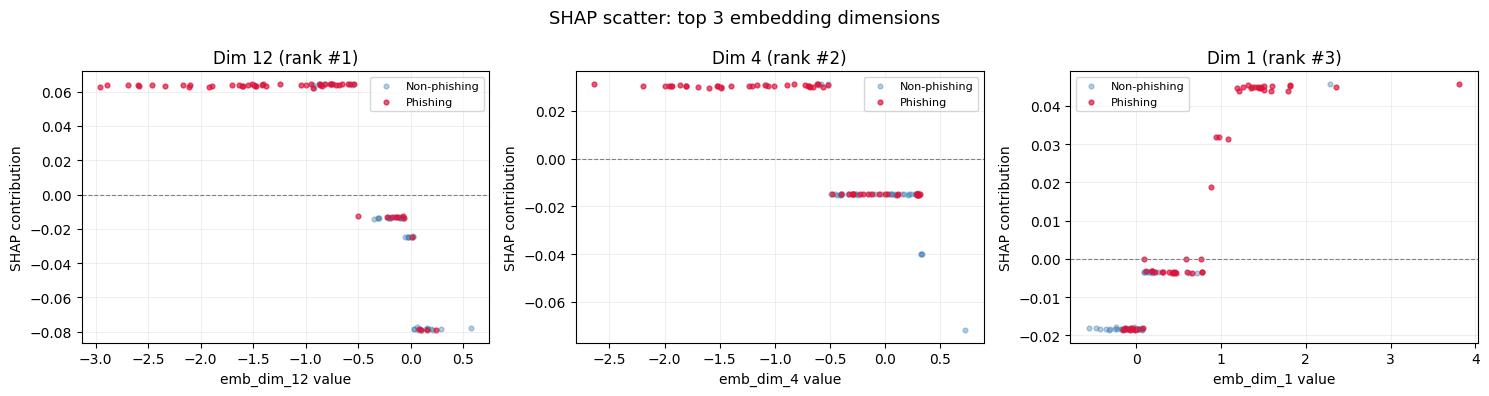


Top 5 most influential embedding dimensions for phishing detection:
  #1: emb_dim_12  (mean |SHAP| = 0.0512)
  #2: emb_dim_4  (mean |SHAP| = 0.0220)
  #3: emb_dim_1  (mean |SHAP| = 0.0196)
  #4: emb_dim_11  (mean |SHAP| = 0.0161)
  #5: emb_dim_6  (mean |SHAP| = 0.0121)


In [ ]:

X_tr_shap, X_te_shap, y_tr_shap, y_te_shap = train_test_split(
    X_gae_bal, y_gae_bal, test_size=0.2, random_state=42, stratify=y_gae_bal
)

ada_shap = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100, random_state=42
)
ada_shap.fit(X_tr_shap, y_tr_shap)

feature_names = [f"emb_dim_{i}" for i in range(X_gae_bal.shape[1])]

background = shap.kmeans(X_tr_shap, 50)

explainer = shap.KernelExplainer(
    lambda x: ada_shap.predict_proba(x)[:, 1],
    background
)

X_explain = X_te_shap[:100]
y_explain  = y_te_shap[:100]

print(f"  Explaining {len(X_explain)} test samples")
shap_values = explainer.shap_values(X_explain, silent=True)

print("Done")

mean_shap  = np.abs(shap_values).mean(axis=0)
sorted_idx = np.argsort(mean_shap)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(len(mean_shap)), mean_shap[sorted_idx],
        color="steelblue", edgecolor="white")
plt.xticks(range(len(mean_shap)),
           [feature_names[i] for i in sorted_idx],
           rotation=45, ha="right", fontsize=9)
plt.ylabel("Mean |SHAP value|")
plt.title("Which embedding dims drive phishing detection?")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

top3_dims = sorted_idx[:3]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, dim in zip(axes, top3_dims):
    phishing_mask = y_explain == 1
    ax.scatter(X_explain[~phishing_mask, dim], shap_values[~phishing_mask, dim],
               alpha=0.4, s=12, c="steelblue", label="Non-phishing")
    ax.scatter(X_explain[phishing_mask,  dim], shap_values[phishing_mask,  dim],
               alpha=0.7, s=12, c="crimson",    label="Phishing")
    ax.set_xlabel(f"emb_dim_{dim} value")
    ax.set_ylabel("SHAP contribution")
    ax.set_title(f"Dim {dim} (rank #{np.where(sorted_idx == dim)[0][0] + 1})")
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

plt.suptitle("SHAP scatter: top 3 embedding dimensions", fontsize=13)
plt.tight_layout()
plt.show()

print("\nTop 5 most influential embedding dimensions for phishing detection:")
for rank, idx in enumerate(sorted_idx[:5], 1):
    print(f"  #{rank}: emb_dim_{idx}  (mean |SHAP| = {mean_shap[idx]:.4f})")

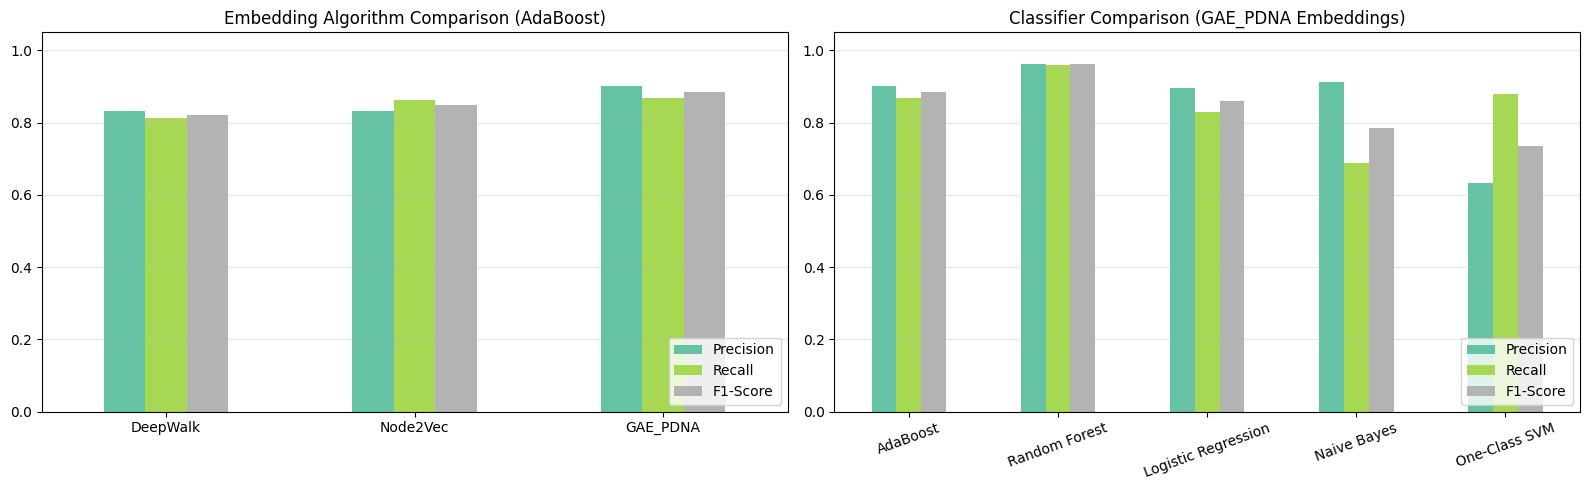

Saved: comparison_charts.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_emb_plot = pd.DataFrame(embed_comparison).T[["Precision", "Recall", "F1-Score"]]
df_emb_plot.plot(kind="bar", ax=axes[0], rot=0, colormap="Set2")
axes[0].set_title("Embedding Algorithm Comparison (AdaBoost)")
axes[0].set_ylim(0, 1.05)
axes[0].legend(loc="lower right")
axes[0].grid(axis="y", alpha=0.3)

df_clf_plot = pd.DataFrame(results_gae).T[["Precision", "Recall", "F1-Score"]]
df_clf_plot.plot(kind="bar", ax=axes[1], rot=20, colormap="Set2")
axes[1].set_title("Classifier Comparison (GAE_PDNA Embeddings)")
axes[1].set_ylim(0, 1.05)
axes[1].legend(loc="lower right")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("comparison_charts.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: comparison_charts.png")


In [ ]:
torch.save(model_gae.state_dict(), "gae_pdna_weights.pth")
torch.save(model_mag.state_dict(), "magnet_weights.pth")

np.save("embeddings_gae_pdna.npy", embeddings_gae)
np.save("embeddings_deepwalk.npy",  embeddings_deepwalk)
np.save("embeddings_node2vec.npy",  embeddings_node2vec)

print("Saved files:")
print("  gae_pdna_weights.pth")
print("  magnet_weights.pth")
print("  embeddings_gae_pdna.npy")
print("  embeddings_deepwalk.npy")
print("  embeddings_node2vec.npy")


Saved files:
  gae_pdna_weights.pth
  magnet_weights.pth
  embeddings_gae_pdna.npy
  embeddings_deepwalk.npy
  embeddings_node2vec.npy


In [ ]:
try:
    from google.colab import files
    for f in ["gae_pdna_weights.pth", "magnet_weights.pth",
              "embeddings_gae_pdna.npy", "tsne_gae_pdna.png", "comparison_charts.png"]:
        if os.path.exists(f):
            files.download(f)
            print(f"  Downloaded: {f}")
except ImportError:
    print("Not running in Colab — files saved locally.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded: gae_pdna_weights.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  Downloaded: embeddings_gae_pdna.npy


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded: comparison_charts.png
